<a href="https://colab.research.google.com/github/Voidneon/SA2---Implementing-YOLOv26-with-NMS-Free-Detection/blob/main/SA2_Gr16_Gonzales_Bagallon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Group 16
- Gonzales, Dominic Ryan
- Bagallon, Radzie

Annotations later code for now. Attempting to make it work first

In [ ]:
import pandas as pd
# Pandas is used as to organize the hyperparameter settings and validation metrics(Precision, Recall, mAP50) into formatted tables.
# it's a foundational tool used in the code base for structured data manipulation and creation of tabular reports.
from google.colab import drive
# from google.colab import drive enables us to have a connection from colab to google drive, which allows us to access the vehicle dataset
# It depends from user to user as they have to connect to their own PERSONAL google drive, the dataset is available in our github
# https://github.com/Voidneon/SA2---Implementing-YOLOv26-with-NMS-Free-Detection
import torch
# torch is a deep learning framework that powers YOLO architecture and provides direct interface tools for the GPU.
# in our usecase, we use it to clear the VRAM cache to ensure the cloud GPU has enough memory to start the next training config.
import gc
# the gc moduele provides an interface to the python garbage collector.
# by calling gc.collect() after each model, we ensure memory from the previous training run is released.
import matplotlib.pyplot as plt
# The primary library used to generate charts and diagnostic images.
# We utilize it here to create a grouped bar chart to visually compare the performance of models 1 to 3 side by side.
import numpy as np
# Numpy is a computing library used for handling large arrays and performing mathematical operations.
# These lines import our libraries/tools to use in our application of the annotated dataset onto several configs of YoloV26 nano
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [ ]:
!uv pip install ultralytics
# Command uses the uv package manager to install the ultralytics library
# Installing this enables our book to have access to the YOLOv26 architecture
import ultralytics
# it imports the ultralytics package/library into our notebook
# It allows access to YOLO and other high-level frameworks needed to run diagnostics and manage the model
from ultralytics import YOLO
# this one imports the YOLO class specifically
# it allows us to initialize the yolo26n.pt(yolov26 nano)

Using Python 3.12.12 environment at: /usr
Audited 1 package in 147ms


In [ ]:
ultralytics.checks()
# This runs a diagnostic check of our environment to verify that our CPU,GPU(Tesla T4) and sof  tware dependencies are correctly configured
# It ensures that our Colab session has "Setup complete" so that we dont encounter hardware errors during training.

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.6/112.6 GB disk)


In [ ]:
drive.mount('/content/drive')
# This command links our Google Drive to the Colab environment, making our cloud files accessible as if theyre on local disk.
# It's critical so that the model can read our data.yaml and images stored in the annotated dataset(Vehicle_Detection)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
configs = [
    {'epochs': 25, 'optimizer': 'AdamW', 'batch': 4, 'lr0': 0.01, 'name': 'Model1_AdamW'},
    {'epochs': 30, 'optimizer': 'SGD', 'batch': 20, 'lr0': 0.001, 'name': 'Model2_SGD'},
    {'epochs': 40, 'optimizer': 'auto', 'batch': -1, 'lr0': 0.0001, 'name': 'Model3_Auto'}
]

# This whole block is the hardcoded list of dictionaries that defines the parameter setups.
# It allows the code to loop through different configurations (AdamW vs SGD vs Auto) to see which one detects vehicles better.

In [ ]:
results_list = []
# Initializes the aempty array we made to store the performance data from each model
# We do this so that the results from model 1 and 2 aren't overwritten when the metrics from model 3 are gathered
metrics = ['mAP50', 'Precision', 'Recall', 'F1 Score']
# It's a reference for the specific values we need to track and visualize
# We need to keep track of them because we use them to compare/evaluate the models

In [ ]:
for cfg in configs:
    # This loop contains all the training and validation steps to ensure the conifg we setup is being processed.
    # For each iteration the variable cfg holds the specific setting(epochs,optimizer,batch size) for model 1, model 2 model 3

    print(f"--- Starting Training: {cfg['name']} ---")
    # This print statement provides a visual cue in the console to confirm which model is currently active.
    # It serves as a checkpoint to monitor the loop's progression through the Model1, Model2, and Model3 setups.

    model = YOLO('yolo26n.pt')
    # Instantiates a fresh YOLOv26 nano model
    # Placing this inside the loop ensures that each model starts from the same weights, so it doesnt carry over from the prev config


    model.train(
        data='/content/drive/MyDrive/Vehicle_detection/data.yaml',
        imgsz=640,
        **cfg
    )
    # The **cfg syntax lets us unpack the dictionary, it takes the keys in the cfg dictionary
    # unpacks the dictionary values directly into the model's training parameters.

    metrics = model.val()
    # After training the model runs a validation check on the valid images to see how well it does on vehicles it hasn't seen before
    # This line produces our final mAP50 scores, essential for checking how effective the different options are.

    p = metrics.results_dict['metrics/precision(B)']
    # Extracts Precision from metrics
    r = metrics.results_dict['metrics/recall(B)']
    # Extracts Recall from metrics
    # Both of these are variable intializations that harness recall and precision to use in expressing validation results.
    f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
    # This manually calculates our models F1 Scores, we extract both recall and precision because F1 score is the harmonic mean of precision and recall.
    # A source for this is: https://bioinfopublication.org/files/articles/2_1_1_JMLT.pdf

    results_list.append({
        'Model': cfg['name'],
        'Optimizer': cfg['optimizer'],
        'mAP50': metrics.results_dict['metrics/mAP50(B)'],
        'Precision': p,
        'Recall': r,
        'F1 Score': f1
    })
    # Appending the data inside the loop prevents the results of Model 1 and 2 from being overwritten by Model 3.
    # This ensures your final table contains the data for all three hyperparameter configurations.

    del model
    gc.collect()
    torch.cuda.empty_cache()
    # These threelines are to reset the GPU vram
    # del removes the model from memory, gc.collect() triggers python's garbage collector and empty_cache()
    # Tells the GPU to release the reserved memory so that the next training run has all the 15GB ram colab has to offer.

df_metrics = pd.DataFrame(results_list)
print(df_metrics)
# This final command outside the loop prints the complete comparison table for all three models.
# This table is a primary deliverable and should be included in our final PDF report.

--- Starting Training: Model1_AdamW ---
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Vehicle_detection/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Model1_AdamW2, nbs=64, nms=False, opset=None, optimize

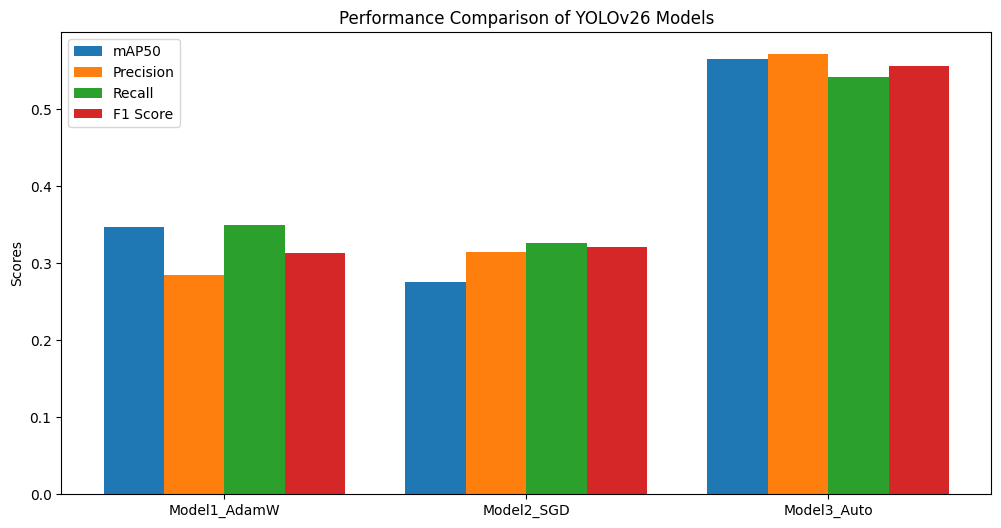

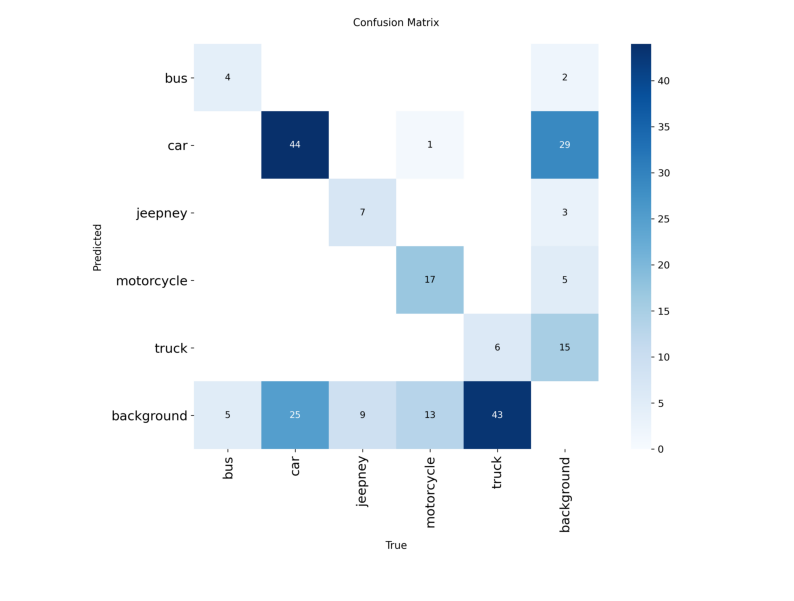

In [ ]:
x = np.arange(len(df_metrics['Model']))
width = 0.2
# The arange function creates an array of label locations for the x-axis based on the number of models trained.
# We set a bar width of 0.2 to ensure that all four metric bars can fit side-by-side without overlapping.

fig, ax = plt.subplots(figsize=(12, 6))
# This line initializes a new figure and a set of subplots with a custom width of 12 inches for better readability.
# Creating an explicit figure object allows us to fine-tune labels and save the output as a high-resolution image file.

rects1 = ax.bar(x - 1.5*width, df_metrics['mAP50'], width, label='mAP50')
rects2 = ax.bar(x - 0.5*width, df_metrics['Precision'], width, label='Precision')
rects3 = ax.bar(x + 0.5*width, df_metrics['Recall'], width, label='Recall')
rects4 = ax.bar(x + 1.5*width, df_metrics['F1 Score'], width, label='F1 Score')
# These four lines draw the individual bars for each metric, offset from the center to create a grouped effect.
# Each call uses a unique label that will automatically be included in the chart's legend for clear identification.

ax.set_ylabel('Scores')
ax.set_title('Performance Comparison of YOLOv26 Models')
ax.set_xticks(x)
ax.set_xticklabels(df_metrics['Model'])
ax.legend()
# These functions set the axis titles and the main chart header to provide context for the performance analysis.
# The legend() call is crucial for ensuring the viewer can distinguish between metrics like Precision and Recall.

plt.savefig('performance_comparison.png')
plt.show()
# The savefig function exports the final chart as a PNG file, which is required for your Part 3 report deliverable.
# Finally, show() renders the visualization in the notebook to verify the data was plotted accurately

matrix_path = 'runs/detect/Model3_Auto/confusion_matrix.png'
# This variable stores the string path to the confusion matrix generated by your highest-performing model configuration.
# It is important to verify this path in your file sidebar, as YOLO may increment folder names if you run the cell multiple times.

img = mpimg.imread(matrix_path)
# The imread function loads the image data into a format that Matplotlib can manipulate and display.
# This step is necessary to bring the external file into the notebook's active memory for visualization.

plt.figure(figsize=(10, 10))
# We initialize a figure with a square 10x10 aspect ratio to ensure the matrix labels are legible.
# Setting a specific figure size prevents the image from appearing too small in the notebook output.

plt.imshow(img)
# The imshow function is the primary tool for rendering the pixel data from the model's diagnostic results.
# It transforms the loaded image array into a visible plot within the Jupyter environment.

plt.axis('off')
# This command hides the X and Y axis pixel coordinates that Matplotlib adds by default to plots.
# Disabling the axis lines provides a cleaner presentation of the confusion matrix for your final PDF report.

plt.show()
# Finally, show() is called to output the prepared visualization directly into the cell's result area.
# This fulfills the deliverable requirement of having the matrix displayed within the notebook for evaluation.